# Semana 1: Introducción al Aprendizaje Automático

## DataQuest - Misión 1: Descubriendo el Poder de los Datos

---

### Objetivos de esta sesión

Al finalizar esta semana, serás capaz de:

1. Explicar qué es el Aprendizaje Automático y diferenciarlo de la programación tradicional
2. Identificar los tres tipos principales de aprendizaje: supervisado, no supervisado y por refuerzo
3. Describir el flujo completo de un proyecto de Machine Learning
4. Usar conceptos clave como features, labels, training set, overfitting, etc.
5. Ejecutar tu primer modelo de ML con Python y scikit-learn

---

## 1. ¿Qué es el Aprendizaje Automático?

### 1.1 Una analogía simple: Aprender a identificar frutas

Imagina que eres un niño pequeño que nunca ha visto una manzana. Tu mamá te muestra varias manzanas:

- "Esto es una manzana" (roja, redonda)
- "Esto también es una manzana" (verde, redonda)
- "Esto también" (amarilla, redonda)

Después de ver muchos ejemplos, **aprendes** a identificar manzanas aunque nunca hayas visto esa manzana específica antes. Tu cerebro encontró **patrones**: forma redonda, cierto tamaño, tiene un tallito arriba.

**El Aprendizaje Automático funciona exactamente igual:**
- Le mostramos a la computadora muchos ejemplos
- La computadora encuentra patrones en esos ejemplos
- Después puede aplicar esos patrones a datos nuevos que nunca ha visto

### 1.2 Definición formal

> **"Un programa de computadora se dice que aprende de la experiencia E con respecto a alguna clase de tareas T y medida de rendimiento P, si su rendimiento en tareas en T, medido por P, mejora con la experiencia E."**
> 
> — Tom Mitchell, 1997

Traducido a español simple:

| Concepto | Ejemplo (Detector de Spam) |
|----------|---------------------------|
| **Tarea (T)** | Clasificar correos como spam o no spam |
| **Experiencia (E)** | Miles de correos ya clasificados |
| **Rendimiento (P)** | % de correos correctamente clasificados |

### 1.3 Programación Tradicional vs Machine Learning

Esta es la diferencia fundamental que debes entender:

```
PROGRAMACIÓN TRADICIONAL:
┌─────────────────────────────────────────────────────┐
│                                                     │
│   DATOS  ────┐                                      │
│              │                                      │
│              ▼                                      │
│         ┌─────────┐                                 │
│         │PROGRAMA │ ──────────►  RESULTADO          │
│         │(Reglas) │                                 │
│         └─────────┘                                 │
│              ▲                                      │
│              │                                      │
│   REGLAS ────┘  (El programador escribe las reglas) │
│                                                     │
└─────────────────────────────────────────────────────┘

MACHINE LEARNING:
┌─────────────────────────────────────────────────────┐
│                                                     │
│   DATOS  ────┐                                      │
│              │                                      │
│              ▼                                      │
│         ┌─────────┐                                 │
│         │ALGORITMO│ ──────────►  REGLAS (Modelo)    │
│         │   ML    │                                 │
│         └─────────┘                                 │
│              ▲                                      │
│              │                                      │
│ RESULTADOS ──┘  (La máquina descubre las reglas)    │
│ ESPERADOS                                           │
└─────────────────────────────────────────────────────┘
```

### 1.4 Ejemplo concreto: Detectar spam

**Enfoque tradicional (reglas manuales):**
```python
def es_spam_tradicional(correo):
    if "gratis" in correo.lower():
        return True
    if "ganaste" in correo.lower():
        return True
    if "viagra" in correo.lower():
        return True
    if correo.count("!") > 5:
        return True
    # ... cientos de reglas más ...
    return False
```

**Problemas:**
- Tienes que pensar en TODAS las reglas posibles
- Los spammers cambian sus tácticas y tus reglas quedan obsoletas
- Es imposible capturar patrones complejos

**Enfoque Machine Learning:**
```python
# Le damos miles de ejemplos de spam y no-spam
modelo.fit(correos_ejemplo, etiquetas_spam_o_no)

# El modelo aprende los patrones solo
prediccion = modelo.predict(correo_nuevo)
```

**Ventajas:**
- El modelo descubre patrones que ni siquiera imaginabas
- Se puede re-entrenar con nuevos datos cuando los spammers cambien
- Captura combinaciones complejas de características

### 1.5 Breve historia del Machine Learning

```
1950s          1980s          2000s          2010s          2020s
  │              │              │              │              │
  ▼              ▼              ▼              ▼              ▼
┌────┐        ┌─────┐        ┌─────┐        ┌─────┐        ┌─────┐
│Test│        │Redes│        │SVM, │        │Deep │        │GPT, │
│de  │        │Neuro│        │RF,  │        │Learn│        │LLMs │
│Turi│        │nales│        │XGB  │        │ing  │        │     │
│ng  │        │     │        │     │        │CNN  │        │     │
└────┘        └─────┘        └─────┘        └─────┘        └─────┘
  │              │              │              │              │
  │              │              │              │              │
"¿Pueden      "Inviernos     "ML se vuelve  "Big Data +   "IA en todo:"
 las máquinas  del AI"        práctico"      GPUs = boom"  ChatGPT,"
 pensar?"                                                  DALL-E"
```

**Momentos clave:**
- **1950**: Alan Turing propone el "Test de Turing"
- **1957**: Frank Rosenblatt crea el Perceptrón
- **1997**: Deep Blue (IBM) vence a Kasparov en ajedrez
- **2012**: AlexNet revoluciona visión por computadora
- **2016**: AlphaGo vence al campeón mundial de Go
- **2022-2024**: ChatGPT, GPT-4, Claude y la revolución de LLMs

---

## 2. Tipos de Aprendizaje Automático

Existen **tres tipos principales** de aprendizaje automático, clasificados según el tipo de supervisión que recibe el algoritmo durante el entrenamiento.

```
                    ┌──────────────────────────────────────┐
                    │     TIPOS DE MACHINE LEARNING        │
                    └──────────────────────────────────────┘
                                      │
           ┌──────────────────────────┼──────────────────────────┐
           │                          │                          │
           ▼                          ▼                          ▼
   ┌───────────────┐         ┌───────────────┐         ┌───────────────┐
   │  SUPERVISADO  │         │NO SUPERVISADO │         │ POR REFUERZO  │
   │               │         │               │         │               │
   │ Datos con     │         │ Datos sin     │         │ Agente que    │
   │ etiquetas     │         │ etiquetas     │         │ aprende por   │
   │               │         │               │         │ prueba/error  │
   └───────┬───────┘         └───────┬───────┘         └───────────────┘
           │                         │
     ┌─────┴─────┐             ┌─────┴─────┐
     │           │             │           │
     ▼           ▼             ▼           ▼
 Regresión  Clasificación  Clustering  Reducción
 (números)  (categorías)   (grupos)    dimensional
```

### 2.1 Aprendizaje Supervisado

**Analogía:** Es como aprender con un maestro que te dice las respuestas correctas.

- Los datos de entrenamiento incluyen las **etiquetas** (respuestas correctas)
- El modelo aprende la relación entre las características y las etiquetas
- Objetivo: predecir etiquetas para datos nuevos

#### Regresión (predecir números)

Cuando quieres predecir un **valor continuo** (número).

| Ejemplo | Características (X) | Predicción (y) |
|---------|--------------------|-----------------|
| Precio de casa | m², habitaciones, ubicación | $2,500,000 |
| Temperatura mañana | humedad, presión, viento | 28.5°C |
| Ventas del mes | publicidad, temporada, precio | 150,000 unidades |

```
REGRESIÓN: Predecir un número en una línea continua

    Precio
      ▲
      │                          ★ (predicción)
      │                      ●  /
      │                  ●   /
      │              ●    /
      │          ●     /
      │      ●      /   ← Línea aprendida
      │  ●       /
      │      /
      └────────────────────────► Tamaño (m²)
```

C:\Users\Mario\AppData\Local\Temp\ipykernel_56424\2958409527.py:89: UserWarning: Glyph 9733 (\N{BLACK STAR}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\Mario\AppData\Local\Temp\ipykernel_56424\2958409527.py:90: UserWarning: Glyph 9733 (\N{BLACK STAR}) missing from font(s) Arial.
  plt.savefig('regresion_casas_ejemplo.png', dpi=150, bbox_inches='tight')
c:\Users\Mario\Documents\desarrollo\ipn\Cursos\2026\FebreroJulio\content\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 9733 (\N{BLACK STAR}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


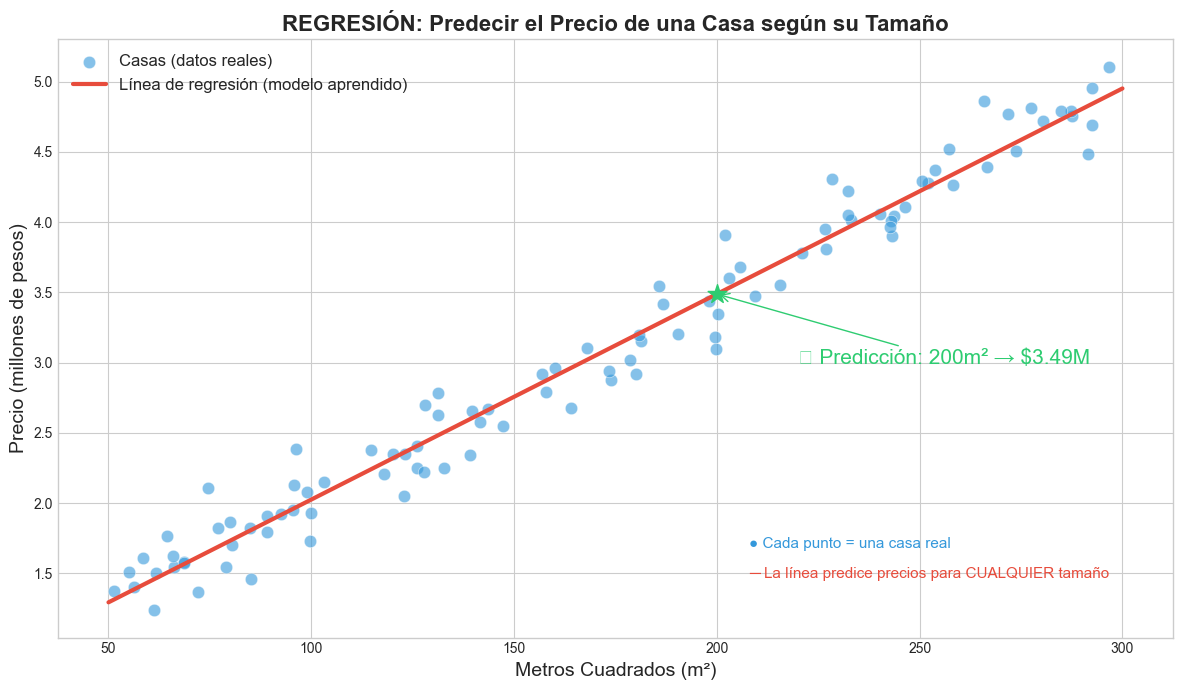

\n📊 INFORMACIÓN DEL MODELO DE REGRESIÓN:
   Precio base (intercepto): $561,410 pesos
   Precio por m² (pendiente): $14,632 pesos/m²
\n   Fórmula aprendida: Precio = 561,410 + (14,632 x m²)
\n💡 Esto significa que por cada m² adicional, el precio sube ~$14,632 pesos


In [1]:
# GRAFICA1: Ejemplo visual de Regresión - Precio de casas vs Metros cuadrados
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression

# Configuración de estilo
plt.style.use('seaborn-v0_8-whitegrid')
np.random.seed(42)

# Generar 100 puntos de datos simulados
n_puntos = 100
metros_cuadrados = np.random.uniform(50, 300, n_puntos)  # Entre 50 y 300 m²

# Precio = relación lineal + ruido aleatorio
# Aproximadamente $15,000 por m² + un precio base + variación
precio_base = 500000  # Precio base en pesos
precio_por_m2 = 15000  # Precio por metro cuadrado
ruido = np.random.normal(0, 200000, n_puntos)  # Variación aleatoria

precio = precio_base + (precio_por_m2 * metros_cuadrados) + ruido

# Crear el modelo de regresión lineal para la línea de interpolación
X = metros_cuadrados.reshape(-1, 1)
y = precio
modelo_regresion = LinearRegression()
modelo_regresion.fit(X, y)

# Predecir para la línea
X_linea = np.linspace(50, 300, 100).reshape(-1, 1)
y_linea = modelo_regresion.predict(X_linea)

# Crear la gráfica
fig, ax = plt.subplots(figsize=(12, 7))

# Gráfica de dispersión (puntos)
scatter = ax.scatter(
    metros_cuadrados, 
    precio / 1000000,  # Convertir a millones para mejor lectura
    c='#3498db',       # Color azul
    alpha=0.6,
    s=80,
    edgecolors='white',
    linewidth=0.5,
    label='Casas (datos reales)'
)

# Línea de regresión (interpolación)
ax.plot(
    X_linea, 
    y_linea / 1000000,  # Convertir a millones
    color='#e74c3c',    # Color rojo
    linewidth=3,
    linestyle='-',
    label=f'Línea de regresión (modelo aprendido)'
)

# Configuración de la gráfica
ax.set_xlabel('Metros Cuadrados (m²)', fontsize=14)
ax.set_ylabel('Precio (millones de pesos)', fontsize=14)
ax.set_title('REGRESIÓN: Predecir el Precio de una Casa según su Tamaño', fontsize=16, fontweight='bold')
ax.legend(loc='upper left', fontsize=12)

# Añadir anotaciones explicativas
ax.annotate(
    '● Cada punto = una casa real',
    xy=(0.62, 0.15), xycoords='axes fraction',
    fontsize=11, color='#3498db'
)
ax.annotate(
    '─ La línea predice precios para CUALQUIER tamaño',
    xy=(0.62, 0.10), xycoords='axes fraction',
    fontsize=11, color='#e74c3c'
)

# Mostrar ejemplo de predicción
ejemplo_m2 = 200
ejemplo_precio = modelo_regresion.predict([[ejemplo_m2]])[0]
ax.scatter([ejemplo_m2], [ejemplo_precio/1000000], c='#2ecc71', s=200, zorder=5, marker='*', label='Predicción nueva')
ax.annotate(
    f'★ Predicción: {ejemplo_m2}m² → ${ejemplo_precio/1000000:.2f}M',
    xy=(ejemplo_m2, ejemplo_precio/1000000),
    xytext=(ejemplo_m2 + 20, ejemplo_precio/1000000 - 0.5),
    fontsize=15,
    color='#2ecc71',
    arrowprops=dict(arrowstyle='->', color='#2ecc71')
)

plt.tight_layout()
plt.savefig('regresion_casas_ejemplo.png', dpi=150, bbox_inches='tight')
plt.show()

# Mostrar información del modelo
print("\\n📊 INFORMACIÓN DEL MODELO DE REGRESIÓN:")
print("="*55)
print(f"   Precio base (intercepto): ${modelo_regresion.intercept_:,.0f} pesos")
print(f"   Precio por m² (pendiente): ${modelo_regresion.coef_[0]:,.0f} pesos/m²")
print(f"\\n   Fórmula aprendida: Precio = {modelo_regresion.intercept_:,.0f} + ({modelo_regresion.coef_[0]:,.0f} x m²)")
print(f"\\n💡 Esto significa que por cada m² adicional, el precio sube ~${modelo_regresion.coef_[0]:,.0f} pesos")

#### Clasificación (predecir categorías)

Cuando quieres predecir una **categoría** o **clase**.

| Ejemplo | Características (X) | Predicción (y) |
|---------|--------------------|-----------------|
| Spam o no | palabras, remitente, enlaces | Spam / No Spam |
| Diagnóstico | síntomas, análisis, edad | Enfermedad A, B, C |
| Reconocer dígitos | píxeles de imagen | 0, 1, 2, ... 9 |

```
CLASIFICACIÓN BINARIA: Separar en dos grupos

    Feature 2
      ▲
      │    ○ ○ ○
      │  ○ ○ ○ ○     ○ = Clase A (ej: No Spam)
      │    ○ ○ \  
      │─────────\─────── ← Frontera de decisión
      │          \ ● ●
      │        ● ● ● ●   ● = Clase B (ej: Spam)
      │          ● ● ●
      └────────────────────► Feature 1
```

C:\Users\Mario\AppData\Local\Temp\ipykernel_56424\1622571109.py:118: UserWarning: Glyph 9733 (\N{BLACK STAR}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\Mario\AppData\Local\Temp\ipykernel_56424\1622571109.py:119: UserWarning: Glyph 9733 (\N{BLACK STAR}) missing from font(s) Arial.
  plt.savefig('clasificacion_spam_ejemplo.png', dpi=150, bbox_inches='tight')
c:\Users\Mario\Documents\desarrollo\ipn\Cursos\2026\FebreroJulio\content\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 9733 (\N{BLACK STAR}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


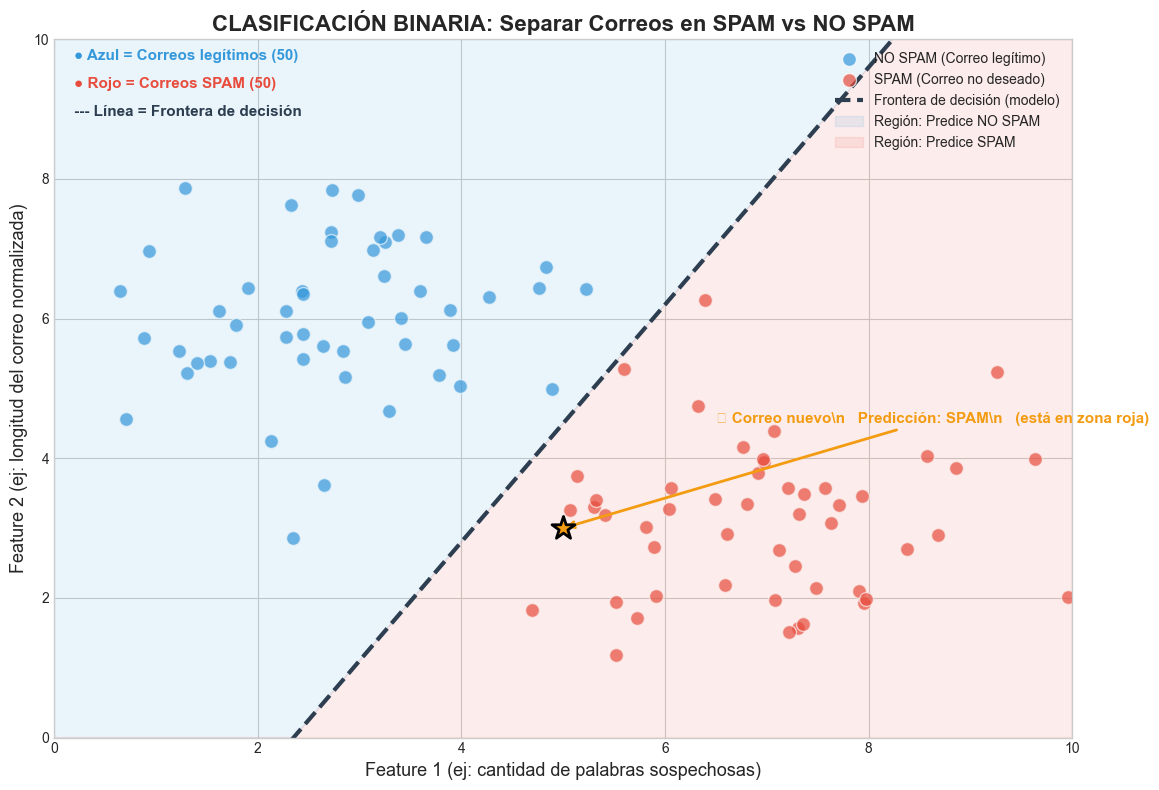

\n📊 EXPLICACIÓN DE LA GRÁFICA:
   • Cada punto representa un correo electrónico
   • Feature 1: podría ser 'cantidad de palabras sospechosas'
   • Feature 2: podría ser 'longitud normalizada del correo'
\n   • La LÍNEA PUNTEADA es la 'frontera de decisión':
     → Puntos ARRIBA de la línea → se predicen como NO SPAM
     → Puntos ABAJO de la línea → se predicen como SPAM
\n💡 El modelo de ML aprende dónde colocar esta línea
   para separar mejor las dos clases de correos.


In [2]:
# GRAFICA2: Ejemplo visual de Clasificación Binaria - Detector de SPAM
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Configuración de estilo
plt.style.use('seaborn-v0_8-whitegrid')
np.random.seed(42)

# Generar 50 puntos para cada clase (100 total)
n_por_clase = 50

# Clase 1: NO SPAM (puntos azules) - cluster arriba a la izquierda
no_spam_x = np.random.normal(3, 1.2, n_por_clase)  # Feature 1
no_spam_y = np.random.normal(6, 1.2, n_por_clase)  # Feature 2

# Clase 2: SPAM (puntos rojos) - cluster abajo a la derecha
spam_x = np.random.normal(7, 1.2, n_por_clase)  # Feature 1
spam_y = np.random.normal(3, 1.2, n_por_clase)  # Feature 2

# Crear la figura
fig, ax = plt.subplots(figsize=(12, 8))

# Graficar puntos NO SPAM (azules)
ax.scatter(
    no_spam_x, no_spam_y,
    c='#3498db',           # Azul
    s=100,
    alpha=0.7,
    edgecolors='white',
    linewidth=1,
    label='NO SPAM (Correo legítimo)',
    marker='o'
)

# Graficar puntos SPAM (rojos)
ax.scatter(
    spam_x, spam_y,
    c='#e74c3c',           # Rojo
    s=100,
    alpha=0.7,
    edgecolors='white',
    linewidth=1,
    label='SPAM (Correo no deseado)',
    marker='o'
)

# Dibujar la línea de decisión (frontera entre clases)
# La línea va de (0, 9) a (10, 0) aproximadamente - diagonal que separa los grupos
x_linea = np.linspace(0, 10, 100)
y_linea = 1.7*x_linea - 4  # Ecuación de la línea: y = -x + 9.5

ax.plot(
    x_linea, y_linea,
    color='#2c3e50',       # Gris oscuro
    linewidth=3,
    linestyle='--',
    label='Frontera de decisión (modelo)'
)

# Colorear las regiones de decisión (fondo semitransparente)
# Región NO SPAM (arriba de la línea)
ax.fill_between(
    x_linea, y_linea, 10,
    alpha=0.1,
    color='#3498db',
    label='Región: Predice NO SPAM'
)

# Región SPAM (abajo de la línea)
ax.fill_between(
    x_linea, 0, y_linea,
    alpha=0.1,
    color='#e74c3c',
    label='Región: Predice SPAM'
)

# Configuración de ejes y título
ax.set_xlim(0, 10)
ax.set_ylim(0, 10)
ax.set_xlabel('Feature 1 (ej: cantidad de palabras sospechosas)', fontsize=13)
ax.set_ylabel('Feature 2 (ej: longitud del correo normalizada)', fontsize=13)
ax.set_title('CLASIFICACIÓN BINARIA: Separar Correos en SPAM vs NO SPAM', fontsize=16, fontweight='bold')

# Leyenda
ax.legend(loc='upper right', fontsize=10)

# Añadir anotaciones explicativas
ax.annotate(
    '● Azul = Correos legítimos (50)',
    xy=(0.02, 0.97), xycoords='axes fraction',
    fontsize=11, color='#3498db', fontweight='bold'
)
ax.annotate(
    '● Rojo = Correos SPAM (50)',
    xy=(0.02, 0.93), xycoords='axes fraction',
    fontsize=11, color='#e74c3c', fontweight='bold'
)
ax.annotate(
    '--- Línea = Frontera de decisión',
    xy=(0.02, 0.89), xycoords='axes fraction',
    fontsize=11, color='#2c3e50', fontweight='bold'
)

# Mostrar un punto de ejemplo con predicción
ejemplo_x, ejemplo_y = 5, 3
ax.scatter([ejemplo_x], [ejemplo_y], c='#f39c12', s=300, marker='*', zorder=5, edgecolors='black', linewidth=2)
ax.annotate(
    f'★ Correo nuevo\\n   Predicción: SPAM\\n   (está en zona roja)',
    xy=(ejemplo_x, ejemplo_y),
    xytext=(ejemplo_x + 1.5, ejemplo_y + 1.5),
    fontsize=11,
    color='#f39c12',
    fontweight='bold',
    arrowprops=dict(arrowstyle='->', color='#f39c12', lw=2)
)

plt.tight_layout()
plt.savefig('clasificacion_spam_ejemplo.png', dpi=150, bbox_inches='tight')
plt.show()

# Información adicional
print("\\n📊 EXPLICACIÓN DE LA GRÁFICA:")
print("="*60)
print("   • Cada punto representa un correo electrónico")
print("   • Feature 1: podría ser 'cantidad de palabras sospechosas'")
print("   • Feature 2: podría ser 'longitud normalizada del correo'")
print("\\n   • La LÍNEA PUNTEADA es la 'frontera de decisión':")
print("     → Puntos ARRIBA de la línea → se predicen como NO SPAM")
print("     → Puntos ABAJO de la línea → se predicen como SPAM")
print("\\n💡 El modelo de ML aprende dónde colocar esta línea")
print("   para separar mejor las dos clases de correos.")

### 2.2 Aprendizaje No Supervisado

**Analogía:** Es como organizar tu closet sin que nadie te diga cómo. Tú encuentras patrones: "estas son camisas", "estos son pantalones", "esto es ropa de invierno".

- Los datos **NO tienen etiquetas**
- El modelo busca **patrones o estructuras** ocultas
- Objetivo: descubrir agrupaciones o simplificar datos

#### Clustering (Agrupamiento)

Encontrar grupos naturales en los datos.

| Ejemplo | ¿Qué agrupa? |
|---------|-------------|
| Segmentación de clientes | Clientes similares en comportamiento de compra |
| Agrupación de noticias | Artículos sobre el mismo tema |
| Detección de anomalías | Transacciones que no pertenecen a ningún grupo normal |

```
CLUSTERING: Descubrir grupos sin etiquetas previas

   ANTES (datos sin etiquetar)       DESPUÉS (grupos descubiertos)
   
      ▲                                    ▲
      │  ·  · ·                            │  ○  ○ ○
      │ ·  · ·  ·                          │ ○  ○ ○  ○   Grupo A
      │    · ·                             │    ○ ○
      │                      ───────►      │
      │        · ·                         │        ● ●
      │      · · · ·                       │      ● ● ● ●   Grupo B
      │        · ·                         │        ● ●
      └─────────────►                      └─────────────►
```


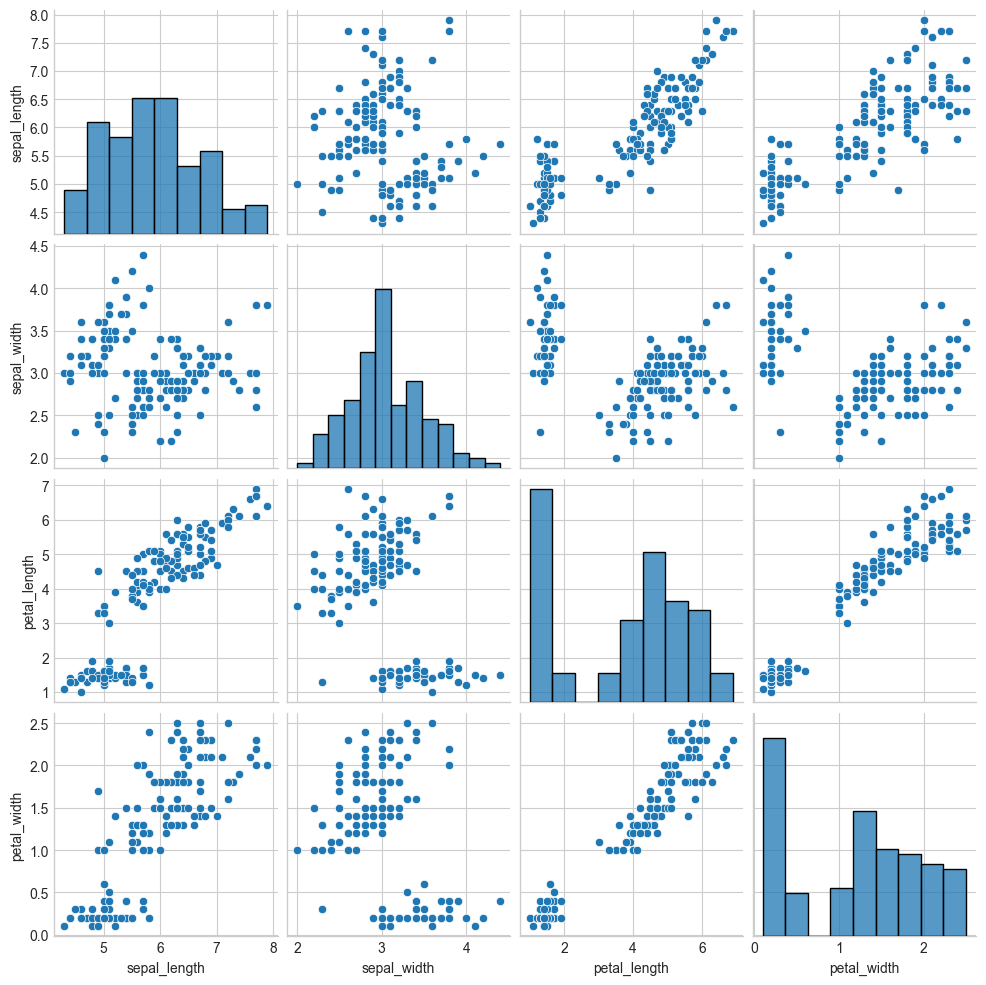

In [3]:
df = sns.load_dataset("iris")
sns.pairplot(df)

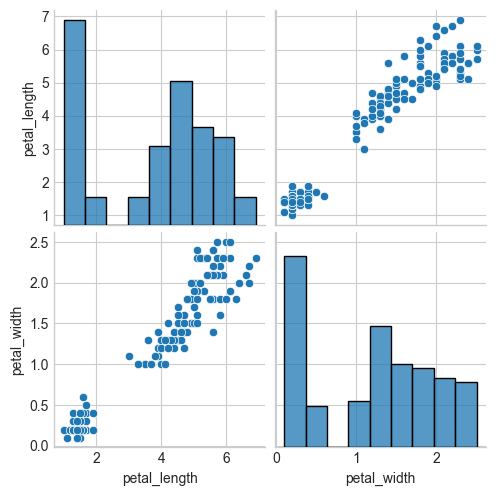

In [4]:

sns.pairplot(df, vars = ["petal_length", "petal_width"])

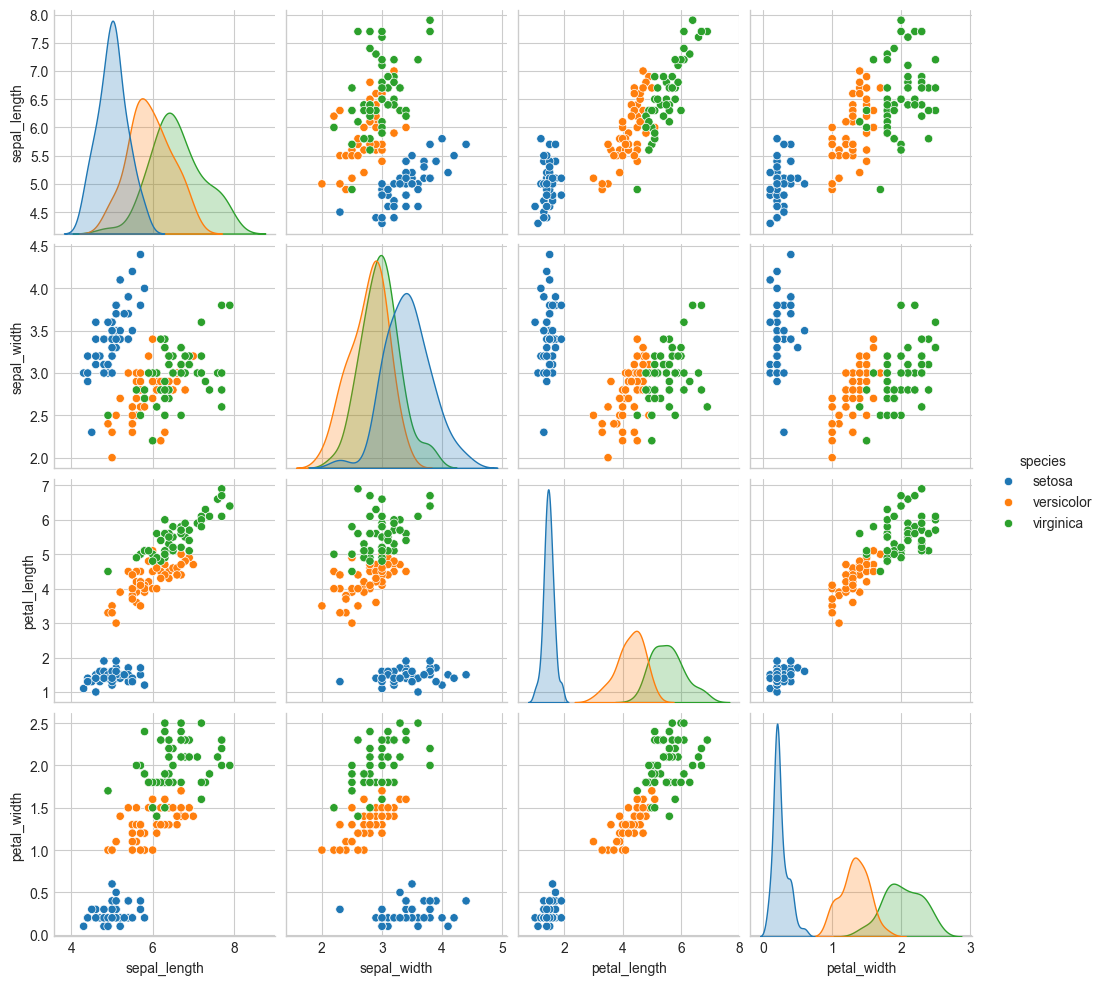

In [5]:
sns.pairplot(df, hue = "species")

#### Reducción de Dimensionalidad

Simplificar datos con muchas variables manteniendo la información importante.

| Ejemplo | ¿Qué reduce? |
|---------|-------------|
| Compresión de imágenes | De millones de píxeles a componentes principales |
| Visualización | De 100 variables a 2D para poder graficar |
| Preprocesamiento | Eliminar variables redundantes antes de modelar |

### 2.3 Aprendizaje por Refuerzo

**Analogía:** Es como entrenar a un perro. No le dices exactamente qué hacer, pero le das premios cuando hace algo bien y lo ignoras (o corriges) cuando hace algo mal.

- Un **agente** interactúa con un **ambiente**
- Recibe **recompensas** o **penalizaciones** según sus acciones
- Aprende la mejor **política** (estrategia) por prueba y error

```
APRENDIZAJE POR REFUERZO

         ┌───────────────────────────────────────────────┐
         │                                               │
         │    ┌─────────┐      Acción      ┌─────────┐   │
         │    │         │ ───────────────► │         │   │
         │    │ AGENTE  │                  │AMBIENTE │   │
         │    │         │ ◄─────────────── │         │   │
         │    └─────────┘   Estado nuevo   └─────────┘   │
         │         ▲        + Recompensa         │       │
         │         │                             │       │
         │         └─────────────────────────────┘       │
         │                                               │
         └───────────────────────────────────────────────┘

Ejemplo: Robot aprendiendo a caminar
- Acción: mover pierna izquierda
- Estado nuevo: avanzó 10cm
- Recompensa: +1 (¡bien hecho!)
- Acción: mover ambas piernas a la vez
- Estado nuevo: se cayó
- Recompensa: -10 (¡mal!)
```

**Ejemplos famosos:**
- **AlphaGo**: Aprendió a jugar Go mejor que cualquier humano
- **Robots**: Aprenden a caminar, agarrar objetos
- **Videojuegos**: Agentes que juegan Atari, Minecraft, etc.
- **Autos autónomos**: Aprenden a conducir en simuladores

### 2.4 Resumen visual de los tres tipos

| Tipo | Datos | Objetivo | Ejemplo |
|------|-------|----------|---------|
| **Supervisado** | Con etiquetas | Predecir etiquetas | "Este correo es spam" |
| **No Supervisado** | Sin etiquetas | Encontrar patrones | "Hay 3 tipos de clientes" |
| **Por Refuerzo** | Recompensas | Maximizar recompensa total | "Aprendí a ganar en ajedrez" |

```
SUPERVISADO          NO SUPERVISADO          POR REFUERZO

  X → y                   X → ?                Acción → Recompensa
  
📧→"spam"             👥→ grupo 1,2,3         🎮→ +10 puntos
📧→"no spam"          📊→ componentes         🎮→ -5 puntos
📧→"spam"             🖼️→ compresión          🎮→ +100 puntos
```

---

## 3. El Flujo de un Proyecto de Machine Learning

Un proyecto real de ML sigue un proceso iterativo. No es lineal: muchas veces hay que regresar a pasos anteriores.

```
┌─────────────────────────────────────────────────────────────────────────┐
│                    FLUJO DE UN PROYECTO DE ML                           │
└─────────────────────────────────────────────────────────────────────────┘

    ┌──────────┐    ┌──────────┐    ┌───────────┐    ┌──────────┐
    │    1.    │    │    2.    │    │    3.     │    │    4.    │
    │ PROBLEMA │───►│  DATOS   │───►│  PREPRO-  │───►│ MODELADO │
    │          │    │          │    │ CESAMIENTO│    │          │
    └──────────┘    └──────────┘    └───────────┘    └──────────┘
                                                        │       
                          ┌─────────────────────────────┘        
                          ▼                                     
                    ┌──────────┐    ┌──────────┐    ┌──────────┐
                    │    5.    │    │    6.    │    │    7.    │
                    │EVALUACIÓN│◄───│  AJUSTE  │◄───│DESPLIEGUE│
                    │          │    │          │    │          │
                    └──────────┘    └──────────┘    └──────────┘
                          │                                     
                          │ ¿Es suficientemente bueno?
                          │
                    NO ───┴─── SÍ
                    │          │
                    ▼          ▼
              Volver a       Producción
              pasos 2,3,4    
```

### Paso 1: Definir el Problema

**Preguntas clave:**
- ¿Qué quiero predecir o descubrir?
- ¿Es un problema de regresión, clasificación o clustering?
- ¿Cómo voy a medir el éxito?
- ¿Qué impacto tiene resolver este problema?

**Ejemplo:** "Quiero predecir si un cliente dejará de usar nuestro servicio (churn) para poder contactarlo antes y ofrecerle una promoción."

### Paso 2: Obtener los Datos

**Fuentes comunes:**
- Bases de datos internas
- APIs públicas
- Web scraping
- Datasets públicos (Kaggle, UCI, etc.)
- Generación sintética

**Ejemplo:** Exportamos datos de los últimos 2 años de clientes: información demográfica, historial de compras, interacciones con soporte, etc.

### Paso 3: Preprocesamiento

Los datos del mundo real son **sucios**. Hay que limpiarlos:

- Manejar valores faltantes (nulos)
- Eliminar duplicados
- Corregir errores
- Transformar variables (escalado, encoding)
- Crear nuevas características (feature engineering)

**Regla del 80/20:** El 80% del tiempo de un proyecto de ML se va en obtener y limpiar datos.

### Paso 4: Modelado

- Elegir algoritmo(s) candidatos
- Dividir datos en train/validation/test
- Entrenar modelos
- Ajustar hiperparámetros

### Paso 5: Evaluación

- Medir rendimiento con métricas apropiadas
- Comparar diferentes modelos
- Verificar que no hay overfitting
- Evaluar en datos que el modelo nunca ha visto

### Paso 6: Iteración y Ajuste

Si el modelo no es suficientemente bueno:
- Obtener más datos
- Probar otros algoritmos
- Hacer mejor feature engineering
- Ajustar hiperparámetros

### Paso 7: Despliegue

Poner el modelo en producción:
- API REST
- Integración en aplicación existente
- Pipeline automatizado
- Monitoreo continuo

---

## 4. Conceptos Clave que Debes Dominar

Estos términos los usarás todo el curso (y tu carrera). ¡Apréndelos bien!

### 4.1 Features (Características) y Labels (Etiquetas)

```
┌────────────────────────────────────────────────────────────────────┐
│                         DATASET                                    │
├────────────────────────────────────────────────────────────────────┤
│                                                                    │
│   ┌─────────────────────────────────────┐   ┌────────────────┐     │
│   │         FEATURES (X)                │   │   LABEL (y)    │     │
│   │     (Variables de entrada)          │   │   (Objetivo)   │     │
│   ├──────────┬──────────┬───────────────┤   ├────────────────┤     │
│   │  Tamaño  │ Habitac. │   Ubicación   │   │    Precio      │     │
│   ├──────────┼──────────┼───────────────┤   ├────────────────┤     │
│   │   120m²  │    3     │   Colonia X   │   │  $2,500,000    │     │
│   │    85m²  │    2     │   Colonia Y   │   │  $1,800,000    │     │
│   │   200m²  │    4     │   Colonia Z   │   │  $4,200,000    │     │
│   │   ...    │   ...    │      ...      │   │      ...       │     │
│   └──────────┴──────────┴───────────────┘   └────────────────┘     │
│                                                                    │
│   Lo que el modelo VE                       Lo que el modelo       │
│   para hacer predicciones                   intenta PREDECIR       │
│                                                                    │
└────────────────────────────────────────────────────────────────────┘
```

**En código:**
```python
X = df[['tamaño', 'habitaciones', 'ubicacion']]  # Features
y = df['precio']                                  # Label
```

**Otros nombres que verás:**
- Features: variables independientes, predictores, inputs, atributos
- Label: variable dependiente, target, output, respuesta

### 4.2 Training Set, Validation Set y Test Set

**¿Por qué dividir los datos?**

Imagina que estudias para un examen solo con las preguntas del examen. Sacarías 100... pero no habrías aprendido nada útil. Lo mismo pasa con ML:

```
┌─────────────────────────────────────────────────────────────────────────┐
│                      DIVISIÓN DE DATOS                                  │
├─────────────────────────────────────────────────────────────────────────┤
│                                                                         │
│  ┌───────────────────────────────────────────────────────────────────┐  │
│  │                     TODOS LOS DATOS                               │  │
│  │                         100%                                      │  │
│  └───────────────────────────────────────────────────────────────────┘  │
│                              │                                          │
│              ┌───────────────┼───────────────┐                          │
│              │               │               │                          │
│              ▼               ▼               ▼                          │
│  ┌───────────────────┐ ┌────────────┐ ┌───────────────┐                 │
│  │   TRAINING SET    │ │VALIDATION  │ │   TEST SET    │                 │
│  │      (70%)        │ │   (15%)    │ │    (15%)      │                 │
│  │                   │ │            │ │               │                 │
│  │ Para APRENDER     │ │Para AJUSTAR│ │ Para EVALUAR  │                 │
│  │ los patrones      │ │el modelo   │ │ al FINAL      │                 │
│  │                   │ │            │ │               │                 │
│  │ Se usa MUCHAS     │ │Se usa para │ │ Se usa UNA    │                 │
│  │ veces             │ │elegir      │ │ SOLA VEZ      │                 │
│  │                   │ │hiperpar.   │ │               │                 │
│  └───────────────────┘ └────────────┘ └───────────────┘                 │
│                                                                         │
└─────────────────────────────────────────────────────────────────────────┘
```

**Analogía escolar:**
- **Training**: Los ejercicios de práctica del libro
- **Validation**: Los exámenes parciales (puedes mejorar después)
- **Test**: El examen final (solo tienes una oportunidad)

### 4.3 Overfitting vs Underfitting

Este es uno de los conceptos MÁS importantes en Machine Learning.

```
        UNDERFITTING              JUST RIGHT               OVERFITTING
       (Muy simple)              (Balanceado)            (Muy complejo)

           │                          │                         │
           ▼                          ▼                         ▼

    Línea recta que           Curva que captura         Curva que pasa por
    no captura el             el patrón general         TODOS los puntos
    patrón                                              (incluyendo el ruido)

    ❌ Mal en TRAIN           ✅ Bien en TRAIN          ✅ Perfecto en TRAIN
    ❌ Mal en TEST            ✅ Bien en TEST           ❌ Mal en TEST
```

**Underfitting (Subajuste):**
- El modelo es demasiado simple
- No captura los patrones de los datos
- Error alto tanto en training como en test
- **Solución**: usar modelo más complejo, agregar features

**Overfitting (Sobreajuste):**
- El modelo es demasiado complejo
- "Memoriza" los datos de entrenamiento incluyendo el ruido
- Error muy bajo en training, pero alto en test
- **Solución**: regularización, más datos, modelo más simple

**El objetivo**: Encontrar el punto medio donde el modelo generaliza bien a datos nuevos.

![Overfitting](OverfittingUnderfitting.png)

### 4.4 Bias-Variance Tradeoff (Introducción)

Esto está relacionado con overfitting/underfitting:



![BiasVarianceTradeoff](BiasVarianceTradeoff.png)

- **Alto Bias** → Underfitting (modelo muy simple)
- **Alta Varianza** → Overfitting (modelo muy complejo)

Lo veremos más a detalle en semanas posteriores.

---

## 5. Práctica: Tu Primer Modelo de Machine Learning

¡Ahora sí, manos al código! Vamos a entrenar nuestro primer modelo usando el famoso dataset **Iris**.

### El Dataset Iris

Es uno de los datasets más famosos en ML. Contiene medidas de 150 flores de iris de 3 especies diferentes.

```
        Setosa              Versicolor            Virginica
          🌸                    🌺                    🌷
          
   Pétalos pequeños      Pétalos medianos      Pétalos grandes
   Sépalos largos        Sépalos medianos      Sépalos largos
```

**Features (4):**
- Largo del sépalo (cm)
- Ancho del sépalo (cm)
- Largo del pétalo (cm)
- Ancho del pétalo (cm)

**Label:** Especie (setosa, versicolor, virginica)

In [6]:
# Primero, instalemos/importemos las bibliotecas necesarias
# Si no las tienes instaladas, ejecuta: pip install numpy pandas scikit-learn matplotlib seaborn

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Configuración para gráficas más bonitas
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12

print("✅ Bibliotecas importadas correctamente!")

✅ Bibliotecas importadas correctamente!


In [7]:
# Cargar el dataset Iris desde scikit-learn
from sklearn.datasets import load_iris

# Cargamos los datos
iris = load_iris()

# Convertimos a DataFrame de pandas para visualizar mejor
df = pd.DataFrame(
    data=iris.data,
    columns=iris.feature_names
)

# Agregamos la columna de especies
df['species'] = iris.target
df['species_name'] = df['species'].map({0: 'setosa', 1: 'versicolor', 2: 'virginica'})

# Veamos las primeras filas
print("🌸 Primeras 10 filas del dataset Iris:")
print("="*70)
df.head(10)

🌸 Primeras 10 filas del dataset Iris:


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species,species_name
0,5.1,3.5,1.4,0.2,0,setosa
1,4.9,3.0,1.4,0.2,0,setosa
2,4.7,3.2,1.3,0.2,0,setosa
3,4.6,3.1,1.5,0.2,0,setosa
4,5.0,3.6,1.4,0.2,0,setosa
5,5.4,3.9,1.7,0.4,0,setosa
6,4.6,3.4,1.4,0.3,0,setosa
7,5.0,3.4,1.5,0.2,0,setosa
8,4.4,2.9,1.4,0.2,0,setosa
9,4.9,3.1,1.5,0.1,0,setosa


In [8]:
# Información básica del dataset
print("📊 INFORMACIÓN DEL DATASET")
print("="*50)
print(f"Número de muestras (filas): {len(df)}")
print(f"Número de features (columnas): {len(iris.feature_names)}")
print(f"\nFeatures:")
for i, name in enumerate(iris.feature_names, 1):
    print(f"  {i}. {name}")

print(f"\nClases (especies):")
for i, name in enumerate(iris.target_names):
    count = (df['species'] == i).sum()
    print(f"  - {name}: {count} muestras")

📊 INFORMACIÓN DEL DATASET
Número de muestras (filas): 150
Número de features (columnas): 4

Features:
  1. sepal length (cm)
  2. sepal width (cm)
  3. petal length (cm)
  4. petal width (cm)

Clases (especies):
  - setosa: 50 muestras
  - versicolor: 50 muestras
  - virginica: 50 muestras


In [9]:
# Estadísticas descriptivas
print("📈 ESTADÍSTICAS DESCRIPTIVAS")
print("="*70)
df.describe().round(2)

📈 ESTADÍSTICAS DESCRIPTIVAS


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
count,150.00,150.00,150.00,150.00,150.00
mean,5.84,3.06,3.76,1.20,1.00
std,0.83,0.44,1.77,0.76,0.82
min,4.30,2.00,1.00,0.10,0.00
25%,5.10,2.80,1.60,0.30,0.00
50%,5.80,3.00,4.35,1.30,1.00
75%,6.40,3.30,5.10,1.80,2.00
max,7.90,4.40,6.90,2.50,2.00


### 5.1 Visualización Exploratoria

Antes de modelar, siempre es buena idea **visualizar** los datos para entenderlos mejor.

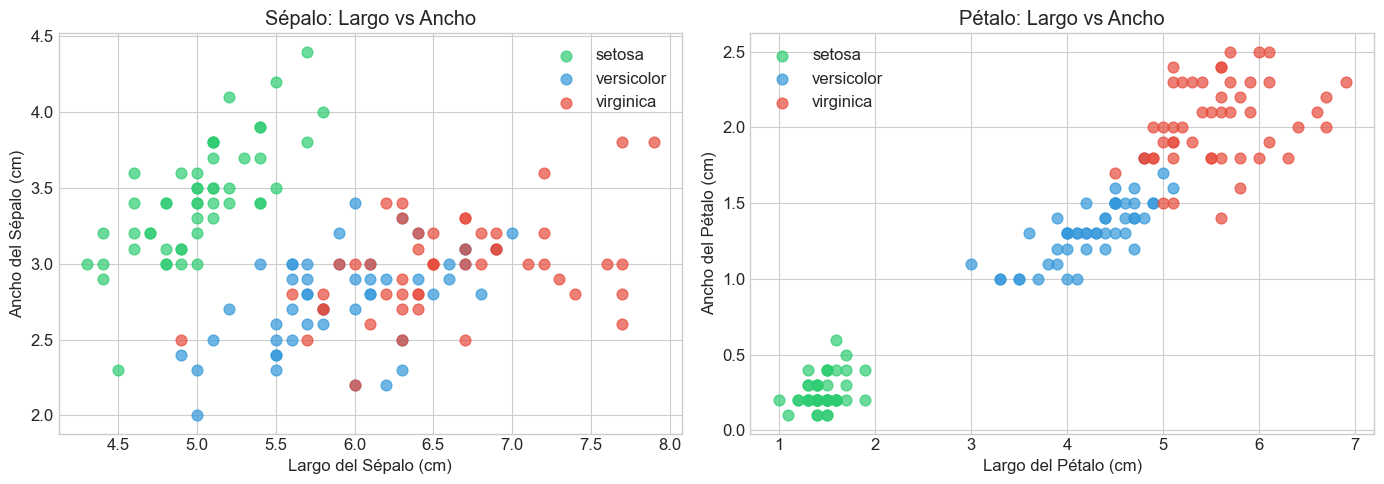


💡 OBSERVACIÓN: Los pétalos separan MUCHO mejor las especies que los sépalos.
   Setosa es claramente diferente. Versicolor y Virginica tienen algo de overlap.


In [10]:
# Gráfica de dispersión: ¿Podemos separar las especies visualmente?
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Gráfica 1: Sépalo
colors = {'setosa': '#2ecc71', 'versicolor': '#3498db', 'virginica': '#e74c3c'}
for species in df['species_name'].unique():
    subset = df[df['species_name'] == species]
    axes[0].scatter(
        subset['sepal length (cm)'],
        subset['sepal width (cm)'],
        label=species,
        c=colors[species],
        alpha=0.7,
        s=60
    )
axes[0].set_xlabel('Largo del Sépalo (cm)')
axes[0].set_ylabel('Ancho del Sépalo (cm)')
axes[0].set_title('Sépalo: Largo vs Ancho')
axes[0].legend()

# Gráfica 2: Pétalo
for species in df['species_name'].unique():
    subset = df[df['species_name'] == species]
    axes[1].scatter(
        subset['petal length (cm)'],
        subset['petal width (cm)'],
        label=species,
        c=colors[species],
        alpha=0.7,
        s=60
    )
axes[1].set_xlabel('Largo del Pétalo (cm)')
axes[1].set_ylabel('Ancho del Pétalo (cm)')
axes[1].set_title('Pétalo: Largo vs Ancho')
axes[1].legend()

plt.tight_layout()
plt.savefig('iris_scatter.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n💡 OBSERVACIÓN: Los pétalos separan MUCHO mejor las especies que los sépalos.")
print("   Setosa es claramente diferente. Versicolor y Virginica tienen algo de overlap.")

🔗 MATRIZ DE CORRELACIÓN


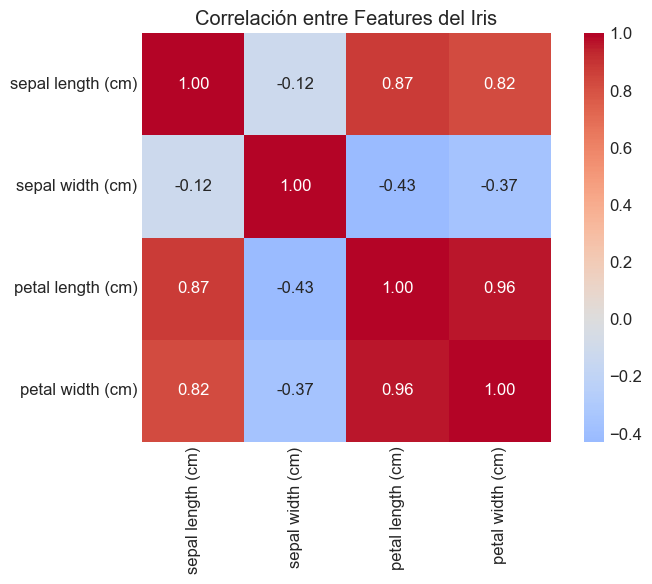


💡 OBSERVACIÓN: Las medidas de pétalo están muy correlacionadas entre sí (0.96)
   Esto tiene sentido: pétalos largos tienden a ser también anchos.


In [11]:
# Matriz de correlación y pairplot
print("🔗 MATRIZ DE CORRELACIÓN")
print("="*50)

# Correlación entre features
correlation = df[iris.feature_names].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(
    correlation,
    annot=True,
    cmap='coolwarm',
    center=0,
    fmt='.2f',
    square=True
)
plt.title('Correlación entre Features del Iris')
plt.tight_layout()
plt.savefig('iris_correlation.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n💡 OBSERVACIÓN: Las medidas de pétalo están muy correlacionadas entre sí (0.96)")
print("   Esto tiene sentido: pétalos largos tienden a ser también anchos.")

### 5.2 Preparar los Datos para el Modelo

In [38]:
from sklearn.model_selection import train_test_split

###################################################################
# PROBAR 42, 77, 33 
RANDOM_VALUE = 33

# Definir X (features) e y (label)
X = df[iris.feature_names]  # Las 4 medidas
y = df['species']           # La especie (0, 1, o 2)

print("📦 PREPARACIÓN DE DATOS")
print("="*50)
print(f"X (features) shape: {X.shape}  → {X.shape[0]} muestras, {X.shape[1]} features")
print(f"y (labels) shape: {y.shape}    → {y.shape[0]} etiquetas")

# Dividir en train (80%) y test (20%)
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,      # 20% para test
    random_state=RANDOM_VALUE,    # Para reproducibilidad
                        
    stratify=y          # Mantener proporciones de clases
)

print(f"\n🔀 DIVISIÓN TRAIN/TEST:")
print(f"   Training: {len(X_train)} muestras ({len(X_train)/len(X)*100:.0f}%)")
print(f"   Test:     {len(X_test)} muestras ({len(X_test)/len(X)*100:.0f}%)")

# Verificar que las proporciones se mantienen
print(f"\n📊 Distribución de clases en Training:")
for i, name in enumerate(iris.target_names):
    count = (y_train == i).sum()
    print(f"   {name}: {count} ({count/len(y_train)*100:.1f}%)")

📦 PREPARACIÓN DE DATOS
X (features) shape: (150, 4)  → 150 muestras, 4 features
y (labels) shape: (150,)    → 150 etiquetas

🔀 DIVISIÓN TRAIN/TEST:
   Training: 120 muestras (80%)
   Test:     30 muestras (20%)

📊 Distribución de clases en Training:
   setosa: 40 (33.3%)
   versicolor: 40 (33.3%)
   virginica: 40 (33.3%)


### 5.3 Entrenar un Modelo de Clasificación

Usaremos un **Árbol de Decisión** (Decision Tree) porque es:
- Fácil de entender
- Visual e interpretable
- No requiere escalado de datos

En las siguientes semanas aprenderemos exactamente cómo funciona.

In [39]:
from sklearn.tree import DecisionTreeClassifier

# Crear el modelo
modelo = DecisionTreeClassifier(
    max_depth=3,        # Profundidad máxima del árbol
    random_state=42     # Para reproducibilidad            
                        
)

# Entrenar el modelo (¡aquí ocurre la magia!)
print("🎓 ENTRENANDO EL MODELO...")
print("="*50)

modelo.fit(X_train, y_train)

print("✅ ¡Modelo entrenado!")
print(f"\n   El modelo aprendió reglas a partir de {len(X_train)} ejemplos.")
print(f"   Profundidad del árbol: {modelo.get_depth()}")
print(f"   Número de hojas: {modelo.get_n_leaves()}")

🎓 ENTRENANDO EL MODELO...
✅ ¡Modelo entrenado!

   El modelo aprendió reglas a partir de 120 ejemplos.
   Profundidad del árbol: 3
   Número de hojas: 4


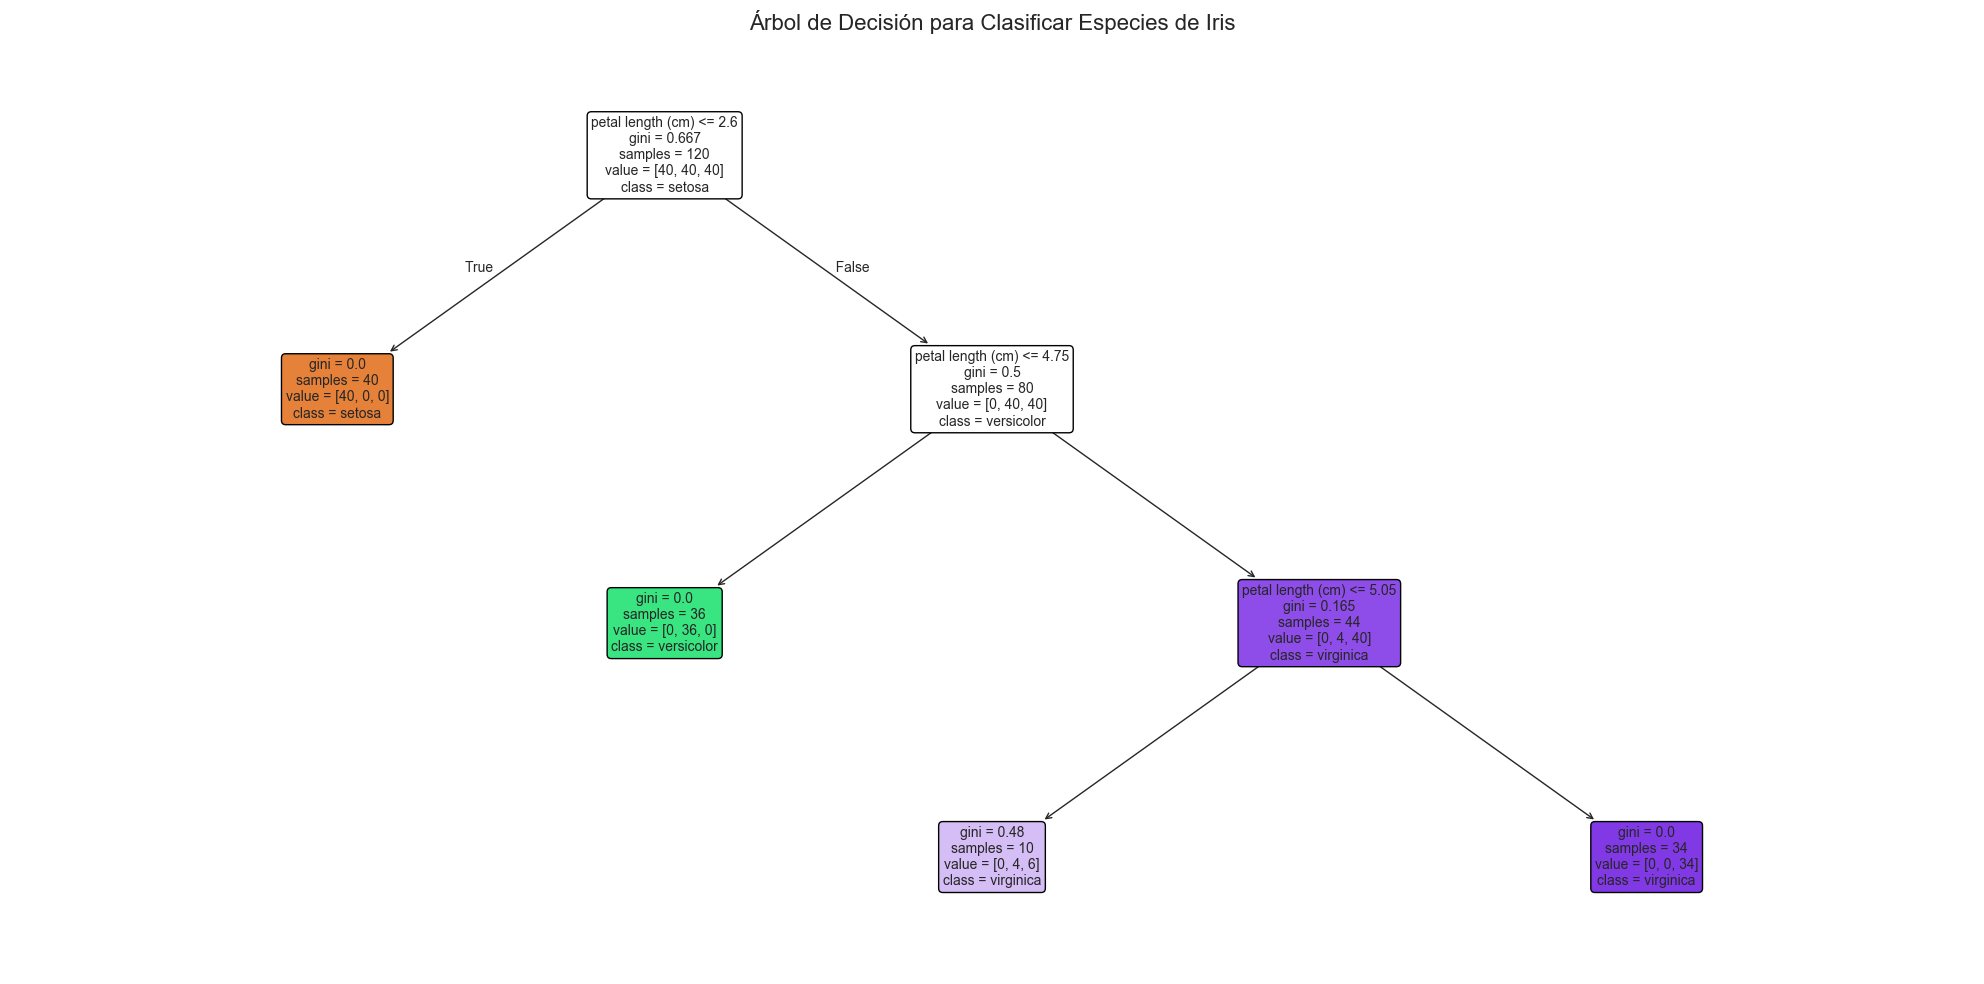


💡 CÓMO LEER EL ÁRBOL:
   - Cada caja es un NODO de decisión
   - La condición (ej: 'petal width <= 0.8') divide los datos
   - 'gini' mide la impureza (0 = perfectamente puro)
   - 'samples' es cuántos ejemplos llegaron a ese nodo
   - 'value' es [#setosa, #versicolor, #virginica]
   - 'class' es la predicción si el nodo fuera hoja


In [40]:
# Visualizar el árbol de decisión
from sklearn.tree import plot_tree

plt.figure(figsize=(20, 10))
plot_tree(
    modelo,
    feature_names=iris.feature_names,
    class_names=iris.target_names,
    filled=True,
    rounded=True,
    fontsize=10
)
plt.title('Árbol de Decisión para Clasificar Especies de Iris', fontsize=16)
plt.tight_layout()
plt.savefig('iris_decision_tree.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n💡 CÓMO LEER EL ÁRBOL:")
print("   - Cada caja es un NODO de decisión")
print("   - La condición (ej: 'petal width <= 0.8') divide los datos")
print("   - 'gini' mide la impureza (0 = perfectamente puro)")
print("   - 'samples' es cuántos ejemplos llegaron a ese nodo")
print("   - 'value' es [#setosa, #versicolor, #virginica]")
print("   - 'class' es la predicción si el nodo fuera hoja")

### 5.4 Evaluar el Modelo

In [41]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Hacer predicciones en el conjunto de test
y_pred = modelo.predict(X_test)

# Calcular accuracy (exactitud)
accuracy = accuracy_score(y_test, y_pred)

print("📊 EVALUACIÓN DEL MODELO")
print("="*50)
print(f"\n🎯 Accuracy (Exactitud): {accuracy:.2%}")
print(f"   → El modelo acertó {int(accuracy * len(y_test))} de {len(y_test)} predicciones")

📊 EVALUACIÓN DEL MODELO

🎯 Accuracy (Exactitud): 90.00%
   → El modelo acertó 27 de 30 predicciones



📋 MATRIZ DE CONFUSIÓN


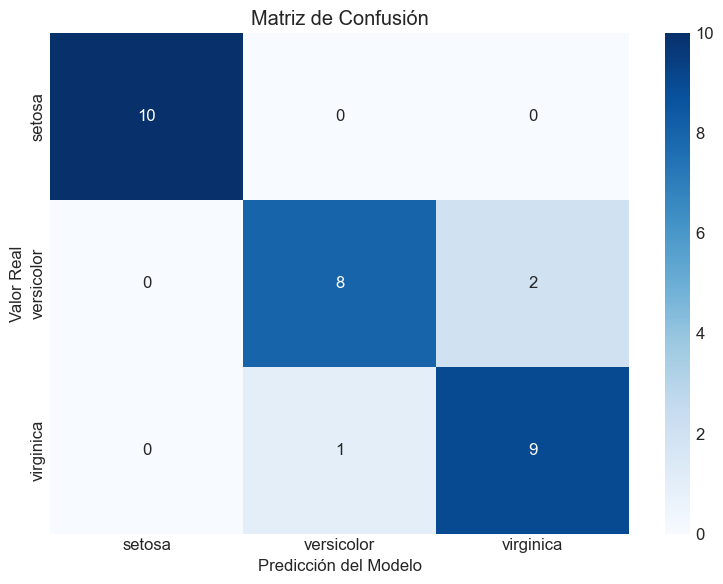


💡 CÓMO LEER LA MATRIZ:
   - Diagonal = predicciones CORRECTAS
   - Fuera de diagonal = ERRORES
   - Ejemplo: 10 setosas fueron clasificadas correctamente


In [42]:
# Matriz de confusión
print("\n📋 MATRIZ DE CONFUSIÓN")
print("="*50)

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=iris.target_names,
    yticklabels=iris.target_names
)
plt.xlabel('Predicción del Modelo')
plt.ylabel('Valor Real')
plt.title('Matriz de Confusión')
plt.tight_layout()
plt.savefig('iris_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n💡 CÓMO LEER LA MATRIZ:")
print("   - Diagonal = predicciones CORRECTAS")
print("   - Fuera de diagonal = ERRORES")
print(f"   - Ejemplo: {cm[0,0]} setosas fueron clasificadas correctamente")

In [25]:
# Reporte de clasificación detallado
print("\n📈 REPORTE DETALLADO POR CLASE")
print("="*60)
print(classification_report(y_test, y_pred, target_names=iris.target_names))

print("\n💡 EXPLICACIÓN DE MÉTRICAS (las veremos a detalle en Semana 10):")
print("   - Precision: De los que predije como X, ¿cuántos realmente son X?")
print("   - Recall: De los que realmente son X, ¿cuántos identifiqué?")
print("   - F1-score: Promedio armónico de precision y recall")
print("   - Support: Número de muestras de cada clase en test")


📈 REPORTE DETALLADO POR CLASE
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      1.00      1.00        10
   virginica       1.00      1.00      1.00        10

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30


💡 EXPLICACIÓN DE MÉTRICAS (las veremos a detalle en Semana 10):
   - Precision: De los que predije como X, ¿cuántos realmente son X?
   - Recall: De los que realmente son X, ¿cuántos identifiqué?
   - F1-score: Promedio armónico de precision y recall
   - Support: Número de muestras de cada clase en test


### 5.5 Hacer Predicciones con Datos Nuevos

In [26]:
# Imaginemos que encontramos una flor nueva y queremos clasificarla

print("🌸 PREDICCIÓN PARA UNA FLOR NUEVA")
print("="*50)

# Medidas de nuestra flor misteriosa
flor_nueva = [[5.1, 3.5, 1.4, 0.2]]  # [sepal_length, sepal_width, petal_length, petal_width]

print(f"\nMedidas de la flor:")
print(f"   Largo del sépalo: {flor_nueva[0][0]} cm")
print(f"   Ancho del sépalo: {flor_nueva[0][1]} cm")
print(f"   Largo del pétalo: {flor_nueva[0][2]} cm")
print(f"   Ancho del pétalo: {flor_nueva[0][3]} cm")

# Hacer la predicción
prediccion = modelo.predict(flor_nueva)
probabilidades = modelo.predict_proba(flor_nueva)

print(f"\n🔮 PREDICCIÓN: {iris.target_names[prediccion[0]]}")
print(f"\n📊 Probabilidades por clase:")
for i, nombre in enumerate(iris.target_names):
    print(f"   {nombre}: {probabilidades[0][i]:.1%}")

🌸 PREDICCIÓN PARA UNA FLOR NUEVA

Medidas de la flor:
   Largo del sépalo: 5.1 cm
   Ancho del sépalo: 3.5 cm
   Largo del pétalo: 1.4 cm
   Ancho del pétalo: 0.2 cm

🔮 PREDICCIÓN: setosa

📊 Probabilidades por clase:
   setosa: 100.0%
   versicolor: 0.0%
   virginica: 0.0%


c:\Users\Mario\Documents\desarrollo\ipn\Cursos\2026\FebreroJulio\content\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
c:\Users\Mario\Documents\desarrollo\ipn\Cursos\2026\FebreroJulio\content\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


In [27]:
# Probemos con varias flores nuevas
print("\n🌺 PREDICCIONES PARA VARIAS FLORES")
print("="*70)

flores_nuevas = [
    [5.1, 3.5, 1.4, 0.2],   # Típica setosa
    [6.0, 2.7, 4.5, 1.5],   # Típica versicolor
    [7.2, 3.0, 6.1, 2.3],   # Típica virginica
    [5.8, 2.8, 4.0, 1.2],   # Caso ambiguo
]

print(f"{'Sépalo L':>10} {'Sépalo W':>10} {'Pétalo L':>10} {'Pétalo W':>10} │ {'Predicción':>12}")
print("-" * 70)

for flor in flores_nuevas:
    pred = modelo.predict([flor])[0]
    nombre = iris.target_names[pred]
    print(f"{flor[0]:>10.1f} {flor[1]:>10.1f} {flor[2]:>10.1f} {flor[3]:>10.1f} │ {nombre:>12}")


🌺 PREDICCIONES PARA VARIAS FLORES
  Sépalo L   Sépalo W   Pétalo L   Pétalo W │   Predicción
----------------------------------------------------------------------
       5.1        3.5        1.4        0.2 │       setosa
       6.0        2.7        4.5        1.5 │   versicolor
       7.2        3.0        6.1        2.3 │    virginica
       5.8        2.8        4.0        1.2 │   versicolor


c:\Users\Mario\Documents\desarrollo\ipn\Cursos\2026\FebreroJulio\content\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
c:\Users\Mario\Documents\desarrollo\ipn\Cursos\2026\FebreroJulio\content\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
c:\Users\Mario\Documents\desarrollo\ipn\Cursos\2026\FebreroJulio\content\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
c:\Users\Mario\Documents\desarrollo\ipn\Cursos\2026\FebreroJulio\content\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature nam

---

## 6. Resumen de la Semana 1

### Lo que aprendimos hoy:

| Concepto | Descripción |
|----------|-------------|
| **Machine Learning** | Algoritmos que aprenden patrones de datos en lugar de seguir reglas programadas |
| **Supervisado** | Aprender con datos etiquetados (regresión y clasificación) |
| **No Supervisado** | Encontrar patrones en datos sin etiquetas (clustering) |
| **Por Refuerzo** | Aprender por prueba y error con recompensas |
| **Features (X)** | Variables de entrada que el modelo usa para predecir |
| **Label (y)** | Lo que queremos predecir |
| **Train/Test Split** | Dividir datos para entrenar y evaluar |
| **Overfitting** | Modelo que memoriza en lugar de generalizar |
| **Underfitting** | Modelo demasiado simple que no captura patrones |

### Código esencial:

```python
# 1. Cargar datos
from sklearn.datasets import load_iris
iris = load_iris()
X, y = iris.data, iris.target

# 2. Dividir datos
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

# 3. Crear y entrenar modelo
from sklearn.tree import DecisionTreeClassifier
modelo = DecisionTreeClassifier()
modelo.fit(X_train, y_train)

# 4. Evaluar
from sklearn.metrics import accuracy_score
y_pred = modelo.predict(X_test)
print(f"Accuracy: {accuracy_score(y_test, y_pred):.2%}")

# 5. Predecir datos nuevos
modelo.predict([[5.1, 3.5, 1.4, 0.2]])
```

---

## 7. Recursos Adicionales

### Para profundizar esta semana:

**Videos:**
- [Machine Learning en 6 minutos - StatQuest](https://www.youtube.com/watch?v=Gv9_4yMHFhI)
- [But what is Machine Learning? - 3Blue1Brown](https://www.youtube.com/watch?v=aircAruvnKk)

**Lecturas:**
- Capítulo 1 de "Hands-On Machine Learning" de Aurélien Géron
- [Scikit-learn Tutorial Oficial](https://scikit-learn.org/stable/tutorial/basic/tutorial.html)

**Práctica:**
- Explora otros datasets de sklearn: `load_wine()`, `load_digits()`, `load_breast_cancer()`
- Intenta cambiar parámetros del árbol y observa cómo cambia el accuracy

---

## ¡Prepárate para el Reto de la Semana 1!

En el reto pondrás en práctica todo lo aprendido. La idea es simple pero poderosa:

**¿Puede un humano competir contra una máquina en clasificar pingüinos?**

Tendrás que:
1. Crear reglas manuales para clasificar especies de pingüinos
2. Aplicarlas a datos de prueba
3. Entrenar un modelo de ML
4. Comparar quién lo hace mejor: tú o la máquina

¡Nos vemos en el reto!

---

_Semana 1 - Introducción al Aprendizaje Automático | DataQuest 2026_